# Iteración 3: Anclaje Espacial mediante YOLO-Pose y Reevaluación Geométrica

Tras las dos primeras iteraciones del proyecto, el problema predictivo comenzó a quedar metodológicamente mejor delimitado. La primera fase evidenció que el enfoque micro-biomecánico puro exigía una precisión visual imposible de sostener dada la resolución, el desenfoque por movimiento y la perspectiva diagonal de las retransmisiones televisivas. Aunque la segunda iteración mitigó parte de este problema al desplazarse hacia señales macro-gestuales, dejó abierta una incógnita fundamental: quizá el modelo multimodal (VLM) no fallaba únicamente por la complejidad de las variables solicitadas, sino por su incapacidad intrínseca para localizar con claridad y consistencia las relaciones anatómicas clave sobre una imagen natural sin procesar.

A partir de esta hipótesis, la tercera iteración introduce una innovación arquitectónica significativa en el *pipeline* del proyecto mediante la inyección de una capa explícita de visión por computador tradicional. En lugar de alimentar al VLM exclusivamente con recortes crudos del jugador (RGB), se genera una representación intermedia apoyada en la estimación de pose utilizando YOLOv8-Pose. El objetivo de este modelo no es sustituir la inferencia del VLM, sino actuar como un "anclaje espacial", superponiendo sobre cada fotograma un esqueleto anatómico simplificado que hace explícitas las conexiones entre hombros, caderas, rodillas y tobillos. El resultado es una imagen híbrida donde la textura del jugador coexiste con una guía geométrica estructurada, diseñada para ayudar a la red neuronal a ignorar el ruido visual (ropa, iluminación, fondos complejos) y centrar su atención en la cinemática del cuerpo.

Esta alteración en el sustrato visual obliga a una reformulación paralela de los *prompts* dirigidos al modelo de visión. Las instrucciones dejan de solicitar descripciones sobre la apariencia general del jugador para enfocarse en la interpretación estricta de las relaciones espaciales bidimensionales que marca el esqueleto. El sistema interroga al VLM sobre la inclinación del eje tronco-cadera, los cruces visuales entre segmentos corporales y la orientación proyectada de las extremidades a lo largo de las cuatro fases del disparo. No obstante, el diseño del *prompt* incorpora una cautela metodológica vital para el entorno del *Machine Learning*: instruye al modelo para que trate la pose inferida como una guía de asistencia y no como una verdad biomecánica tridimensional absoluta, dada la inherente distorsión que la perspectiva diagonal introduce en los esqueletos 2D.

El propósito central de este cuaderno de ejecución es poner a prueba esta representación aumentada. Se generará la nueva memoria visual apoyada en los esqueletos de YOLO-Pose y, siguiendo la arquitectura establecida, se inyectará en el Modelo de Lenguaje (LLM) para que deduzca la lateralidad del disparo (`CRUZADO`, `CENTRAL` o `ABIERTO`). En esencia, esta tercera iteración servirá para aislar si el cuello de botella del sistema radica en un problema de percepción geométrica bruta —que el esqueleto debería solucionar— o si la dificultad para predecir un penalti reside en la naturaleza intrínsecamente ambigua y engañosa de la biomecánica del lanzador en los instantes previos al impacto.

### 1. Configuración Base y Precomputación de Pose

Para materializar el anclaje espacial propuesto en la metodología de esta tercera iteración, se implementó un nuevo módulo de preprocesamiento visual. Aunque se conservaron intactas las rutinas fundamentales desarrolladas en las fases previas —como el cálculo dinámico de las cajas delimitadoras, la sincronización temporal respecto al instante exacto del impacto y el reescalado geométrico para preservar la relación de aspecto original—, la arquitectura del código experimentó una profunda modificación. Para generar esta nueva representación intermedia, se importó la librería de visión artificial Ultralytics y se instanció en memoria el modelo preentrenado YOLOv8-Pose, marcando el inicio de la hibridación visual del sistema.

Para superponer la estructura esquelética sobre la fisonomía real del jugador, se diseñó la función específica `aplicar_pose_yolo`. Este método recibe el fotograma previamente recortado y centrado, ejecuta la inferencia geométrica de estimación de puntos clave y devuelve la imagen renderizada con los nodos articulares y sus conexiones trazadas explícitamente sobre el cuerpo. Para evitar interferencias gráficas que pudieran confundir al modelo multimodal durante la etapa de lectura posterior, se desactivó estratégicamente el renderizado de las cajas delimitadoras nativas de la red YOLO, asegurando que el foco atencional recaiga de forma exclusiva sobre la red cinemática de la pose.

Para gestionar de forma eficiente la exigente demanda computacional que supone procesar cientos de vídeos con un modelo de estimación de pose, se introdujo un cambio arquitectónico crítico en el flujo de ejecución del proyecto. A diferencia de las dos iteraciones anteriores, donde la extracción, la codificación en base64 y el envío de fotogramas a la API se realizaban "al vuelo" durante el propio bucle de razonamiento, este script fue concebido como un precomputador independiente. Mediante la función orquestadora `procesar_y_guardar_fase`, el sistema procesa masivamente el conjunto de datos, genera las composiciones híbridas en las cuatro fases temporales estipuladas y exporta físicamente las imágenes resultantes estructuradas en carpetas individuales por vídeo. Este desacoplamiento metodológico permite separar por completo el pesado renderizado gráfico de la posterior inferencia lingüística, garantizando una mayor estabilidad técnica durante el análisis de los datos.

In [1]:
import cv2
import os
import time
import pandas as pd
from ultralytics import YOLO


BASE_DIR = r'C:\Users\david\OneDrive\Desktop\TFT_LLMPenalties2026'
CSV_ORIGINAL_PATH = os.path.join(BASE_DIR, 'labeled_frames_cuttedvids.csv')
VIDEOS_DIR = os.path.join(BASE_DIR, 'modified_videos')
OUTPUT_DIR = os.path.join(BASE_DIR, 'esqueletos_generados_iteracion3')

os.makedirs(OUTPUT_DIR, exist_ok=True)

DF_ORIGINAL = pd.read_csv(CSV_ORIGINAL_PATH)

print("Cargando modelo YOLOv8-Pose...")
modelo_pose = YOLO('yolov8n-pose.pt')



def resize_keep_aspect_ratio(image, target_size=384):
    """Escala una imagen sin deformarla y añade franjas negras."""
    old_h, old_w = image.shape[:2]
    ratio = min(target_size / old_w, target_size / old_h)
    new_w = int(old_w * ratio)
    new_h = int(old_h * ratio)

    if ratio < 1.0:
        interp = cv2.INTER_AREA
    else:
        interp = cv2.INTER_CUBIC

    resized = cv2.resize(image, (new_w, new_h), interpolation=interp)

    delta_w = target_size - new_w
    delta_h = target_size - new_h
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)

    padded_img = cv2.copyMakeBorder(
        resized,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )
    return padded_img


def get_correct_bbox(vid_data, frame_idx_modificado, target_frames=64):
    total_original_frames = len(vid_data)
    if total_original_frames == 0:
        return None

    if total_original_frames > target_frames:
        indice_real = frame_idx_modificado + (total_original_frames - target_frames)
    elif total_original_frames < target_frames:
        padding_size = target_frames - total_original_frames
        indice_real = 0 if frame_idx_modificado < padding_size else frame_idx_modificado - padding_size
    else:
        indice_real = frame_idx_modificado

    indice_real = min(indice_real, len(vid_data) - 1)

    return (
        int(vid_data.iloc[indice_real]['BB_x']),
        int(vid_data.iloc[indice_real]['BB_y']),
        int(vid_data.iloc[indice_real]['BB_w']),
        int(vid_data.iloc[indice_real]['BB_h'])
    )


def get_kick_frame_idx(vid_data, target_frames=64):
    total_orig = len(vid_data)
    kick_rows = vid_data[vid_data['kick_frame'] == 1]
    kick_orig = int(kick_rows.iloc[0]['frame_id']) if len(kick_rows) > 0 else total_orig // 2

    if total_orig > target_frames:
        kick_mod = kick_orig - (total_orig - target_frames)
    elif total_orig < target_frames:
        kick_mod = kick_orig + (target_frames - total_orig)
    else:
        kick_mod = kick_orig

    total_mod = min(total_orig, target_frames)
    return max(0, min(total_mod - 1, kick_mod))


def crop_frame(frame, vid_data, frame_idx, target_frames=64, pad=100):
    """Recorta el jugador usando el Bounding Box y añade padding dinámico."""
    bbox = get_correct_bbox(vid_data, frame_idx, target_frames=target_frames)

    if bbox:
        x, y, w, h = bbox
        H, W, _ = frame.shape
        x1, y1 = max(0, x - pad), max(0, y - pad)
        x2, y2 = min(W, x + w + pad), min(H, y + h + pad)
        recorte = frame[y1:y2, x1:x2]
        return resize_keep_aspect_ratio(recorte, target_size=384)

    return resize_keep_aspect_ratio(frame, target_size=384)


def aplicar_pose_yolo(frame):
    """Aplica YOLO-Pose y devuelve la imagen con el esqueleto dibujado."""
    try:
        resultados = modelo_pose(frame, verbose=False)
        if resultados is None or len(resultados) == 0:
            return frame
        return resultados[0].plot(boxes=False)
    except Exception as e:
        print(f"Error aplicando YOLO-Pose: {e}")
        return frame



def procesar_y_guardar_fase(frames, vid_data, start, end, n_samples, vid_id, nombre_fase):
    segment = list(range(start, end))
    if not segment:
        return

    if len(segment) <= n_samples:
        indices = segment
    else:
        indices = [segment[int(i * len(segment) / n_samples)] for i in range(n_samples)]

    carpeta_video = os.path.join(OUTPUT_DIR, vid_id)
    os.makedirs(carpeta_video, exist_ok=True)

    for enum_idx, frame_idx in enumerate(indices):
        cropped = crop_frame(frames[frame_idx], vid_data, frame_idx)
        frame_esqueleto = aplicar_pose_yolo(cropped)

        ruta_guardado = os.path.join(carpeta_video, f"{nombre_fase}_{enum_idx}.jpg")
        cv2.imwrite(ruta_guardado, frame_esqueleto)


def procesar_video(vid_id):
    """Procesa un vídeo completo y guarda sus cuatro fases con esqueletos."""
    vid_data = DF_ORIGINAL[DF_ORIGINAL['vid_ID'] == vid_id]
    video_path = os.path.join(VIDEOS_DIR, vid_id + '.mp4')

    if not os.path.exists(video_path):
        print(f"  [!] Vídeo {vid_id}.mp4 no encontrado en {VIDEOS_DIR}")
        return

    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    cap.release()

    if not frames:
        print(f"  [!] No se pudieron extraer frames del vídeo {vid_id}")
        return

    kick_idx = get_kick_frame_idx(vid_data)
    total = len(frames)

    procesar_y_guardar_fase(frames, vid_data, 0, max(1, kick_idx - 12), 4, vid_id, "carrera_1")
    procesar_y_guardar_fase(frames, vid_data, max(1, kick_idx - 12), max(2, kick_idx - 1), 6, vid_id, "carrera_2")
    procesar_y_guardar_fase(frames, vid_data, max(0, kick_idx - 1), min(total, kick_idx + 2), 3, vid_id, "impacto")
    procesar_y_guardar_fase(frames, vid_data, min(total, kick_idx + 2), total, 6, vid_id, "seguimiento")



if __name__ == "__main__":
    videos_a_procesar = DF_ORIGINAL['vid_ID'].unique()[:641]

    print(f"=== INICIANDO PRECOMPUTACIÓN DE ESQUELETOS PARA {len(videos_a_procesar)} VÍDEOS ===")

    start_time = time.time()
    for i, vid in enumerate(videos_a_procesar):
        print(f"Procesando [{i+1}/{len(videos_a_procesar)}]: {vid}")
        procesar_video(vid)

    end_time = time.time()

    print(f"\n=== PROCESO COMPLETADO EN {round(end_time - start_time, 2)} SEGUNDOS ===")
    print(f"Las imágenes están listas en: {OUTPUT_DIR}")

Cargando modelo YOLOv8-Pose...
=== INICIANDO PRECOMPUTACIÓN DE ESQUELETOS PARA 641 VÍDEOS ===
Procesando [1/641]: v1_p1_diag
Procesando [2/641]: v1_p2_diag
Procesando [3/641]: v1_p3_diag
Procesando [4/641]: v1_p4_diag
Procesando [5/641]: v1_p5_diag
Procesando [6/641]: v1_p6_diag
Procesando [7/641]: v1_p7_diag
Procesando [8/641]: v1_p8_diag
Procesando [9/641]: v1_p9_diag
Procesando [10/641]: v1_p10_diag
Procesando [11/641]: v1_p11_diag
Procesando [12/641]: v1_p12_diag
Procesando [13/641]: v1_p13_diag
Procesando [14/641]: v1_p14_diag
Procesando [15/641]: v2_p1_diag
Procesando [16/641]: v2_p2_diag
Procesando [17/641]: v2_p3_diag
Procesando [18/641]: v2_p4_diag
Procesando [19/641]: v2_p5_diag
Procesando [20/641]: v2_p6_diag
Procesando [21/641]: v2_p7_diag
Procesando [22/641]: v2_p8_diag
Procesando [23/641]: v2_p9_diag
Procesando [24/641]: v2_p10_diag
Procesando [25/641]: v2_p11_diag
Procesando [26/641]: v2_p12_diag
Procesando [27/641]: v3_p1_diag
Procesando [28/641]: v3_p2_diag
Procesando 

### 2. Generación de Artefactos Visuales: Mosaico de Progresión

Para ilustrar gráficamente la progresión temporal de la estimación de pose y documentar el cambio de representación introducido en esta tercera iteración, se desarrolló un breve *script* auxiliar encargado de generar un mosaico visual. Utilizando la librería OpenCV, el código carga cuatro fotogramas representativos de un mismo lanzamiento —correspondientes a la carrera inicial, la plantada, el impacto y el seguimiento—, estandariza sus dimensiones espaciales y les superpone una etiqueta de texto descriptiva.

In [2]:
import cv2
import numpy as np
import os

img1 = cv2.imread('C:\\Users\\david\\OneDrive\\Desktop\\TFT_LLMPenalties2026\\esqueletos_generados\\v1_p1_diag\\carrera_1_3.jpg')
img2 = cv2.imread('C:\\Users\\david\\OneDrive\\Desktop\\TFT_LLMPenalties2026\\esqueletos_generados\\v1_p1_diag\\carrera_2_3.jpg')
img3 = cv2.imread('C:\\Users\\david\\OneDrive\\Desktop\\TFT_LLMPenalties2026\\esqueletos_generados\\v1_p1_diag\\impacto_1.jpg')
img4 = cv2.imread('C:\\Users\\david\\OneDrive\\Desktop\\TFT_LLMPenalties2026\\esqueletos_generados\\v1_p1_diag\\seguimiento_0.jpg')

if all(img is not None for img in [img1, img2, img3, img4]):
    h, w = img1.shape[:2]
    img2 = cv2.resize(img2, (w, h))
    img3 = cv2.resize(img3, (w, h))
    img4 = cv2.resize(img4, (w, h))

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.6
    color_bg = (0, 0, 0)
    color_fg = (255, 255, 255)
    thickness = 2
    
    def draw_label(img, text, pos):
        (text_w, text_h), _ = cv2.getTextSize(text, font, font_scale, thickness)
        x, y = pos
        cv2.rectangle(img, (x, y - text_h - 5), (x + text_w + 5, y + 5), color_bg, -1)
        cv2.putText(img, text, pos, font, font_scale, color_fg, thickness, cv2.LINE_AA)
        return img

    img1 = draw_label(img1, '1. Fase de Carrera', (10, 25))
    img2 = draw_label(img2, '2. Fase de Planta/Apoyo', (10, 25))
    img3 = draw_label(img3, '3. Fase de Impacto', (10, 25))
    img4 = draw_label(img4, '4. Fase de Seguimiento', (10, 25))

    top_row = np.hstack((img1, img2))
    bottom_row = np.hstack((img3, img4))
    mosaic = np.vstack((top_row, bottom_row))

    output_filename = 'C:\\Users\\david\\OneDrive\\Desktop\\TFT_LLMPenalties2026\\evolucion_esqueleto.jpg'
    cv2.imwrite(output_filename, mosaic)
    print(f"Mosaico generado con éxito y guardado como '{output_filename}'")
else:
    print("Error: No se pudieron cargar una o más imágenes. Verifica los nombres de los archivos.")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\david\\OneDrive\\Desktop\\TFT_LLMPenalties2026\\esqueletos_generados\\v1_p1_diag\\carrera_1_3.jpg'

### 3. Generación de la Memoria Visual: Anclaje Geométrico con YOLO-Pose

Para integrar la representación visual híbrida generada en la etapa de precomputación y optimizar la carga operativa durante la inferencia, se rediseñó el mecanismo de ingestión de datos de la función principal. En lugar de extraer y recortar los fotogramas dinámicamente desde el archivo de vídeo original como se hacía en las iteraciones previas, se implementaron rutinas auxiliares orientadas a leer directamente las imágenes con los esqueletos superpuestos desde el disco duro local. Mediante este enfoque de lectura estática, el sistema recupera ordenadamente los artefactos gráficos de cada fase, los codifica en formato base64 y los empaqueta para su envío al modelo multimodal Qwen2.5-VL, conservando intacta la arquitectura base de comunicación a través de la API y el ensamblaje cronológico de la memoria estructurada.

Para capitalizar la presencia de la red cinemática trazada sobre los fotogramas y abandonar definitivamente las descripciones basadas en texturas, desenfoques o indumentaria, se reestructuró por completo el *prompt* de sistema que rige el comportamiento de la red neuronal. Se instruyó explícitamente al modelo para que ignorase la apariencia general del lanzador y centrara su capacidad analítica estrictamente en interpretar la geometría visual del gesto. A través de este nuevo conjunto de reglas, la atención algorítmica se redirige hacia el análisis de la posición relativa de los puntos articulares, los cruces aparentes entre las extremidades y la orientación de los segmentos anatómicos dibujados. Para mitigar el riesgo de alucinaciones espaciales, se introdujo una cautela metodológica crítica en las instrucciones, exigiendo al modelo que tratara la superposición de líneas como una estimación proyectada en dos dimensiones y no como una certeza anatómica tridimensional, obligándole a canalizar la incertidumbre mediante lenguaje probabilístico.

Para guiar la extracción de estas nuevas características geométricas a lo largo de la secuencia de golpeo, se diseñaron peticiones de usuario específicas para la lectura de la pose en cada marco temporal, manteniendo un régimen de temperatura algorítmica moderada (`temperature=0.3`) para permitir la articulación del texto descriptivo. Durante la aproximación y la plantada, se solicita a la red evaluar la inclinación global del eje tronco-cadera y determinar si el patrón visual de los nodos articulares revela una apertura lateral del cuerpo. En el fotograma del impacto, el análisis se focaliza en la configuración de la cadena formada por la cadera, la rodilla y el tobillo de la pierna activa, buscando identificar la alineación de estas líneas de fuerza. Finalmente, durante la inercia posterior, se evalúa de forma literal si los segmentos del esqueleto se cruzan por delante del eje del torso o si trazan una salida visualmente abierta, consolidando así una memoria textual puramente espacial que servirá como sustrato para la inferencia predictiva final.

In [ ]:
import os
import base64
import pandas as pd
from openai import OpenAI


CLIENT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")

BASE_DIR = r'C:\Users\david\OneDrive\Desktop\TFT_LLMPenalties2026'
OUTPUT_DIR = os.path.join(BASE_DIR, 'esqueletos_generados_iteracion3')

def encode_image_file_to_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def extraer_indice_archivo(nombre_archivo):
    """
    Extrae el índice final de archivos tipo:
    carrera_1_0.jpg, impacto_2.jpg, seguimiento_5.jpg
    """
    nombre_sin_ext = os.path.splitext(nombre_archivo)[0]
    partes = nombre_sin_ext.split("_")
    try:
        return int(partes[-1])
    except:
        return 9999


def cargar_fase_desde_disco(vid_id, nombre_fase):
    carpeta_video = os.path.join(OUTPUT_DIR, vid_id)

    if not os.path.exists(carpeta_video):
        return []

    archivos = [
        a for a in os.listdir(carpeta_video)
        if a.startswith(f"{nombre_fase}_") and a.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    archivos = sorted(archivos, key=extraer_indice_archivo)

    return [
        encode_image_file_to_base64(os.path.join(carpeta_video, archivo))
        for archivo in archivos
    ]


def extract_frames_by_phase_from_disk(vid_id):
    fases = {
        "carrera_1": cargar_fase_desde_disco(vid_id, "carrera_1"),
        "carrera_2": cargar_fase_desde_disco(vid_id, "carrera_2"),
        "impacto": cargar_fase_desde_disco(vid_id, "impacto"),
        "seguimiento": cargar_fase_desde_disco(vid_id, "seguimiento"),
    }

    if all(len(fases[k]) == 0 for k in fases):
        return None

    return fases


def construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def limpiar(texto):
        return texto.strip() if texto else "No se pudo extraer información."

    return (
        f"--- FASE DE CARRERA INICIAL ---\n{limpiar(desc_carrera_1)}\n\n"
        f"--- FASE DE PLANTA/APOYO ---\n{limpiar(desc_carrera_2)}\n\n"
        f"--- FASE DE IMPACTO ---\n{limpiar(desc_impacto)}\n\n"
        f"--- FASE DE SEGUIMIENTO E INERCIA ---\n{limpiar(desc_seguimiento)}"
    )


def generar_memoria_visual(vid_id, pierna):
    fases = extract_frames_by_phase_from_disk(vid_id)
    if not fases:
        return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64:
            return "No hay frames."

        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{img}"}
            })

        try:
            response = CLIENT.chat.completions.create(
                model="local-model",
                messages=[
                    {"role": "system", "content": prompt_sistema},
                    {"role": "user", "content": content}
                ],
                max_tokens=800,
                temperature=0.3
            )
            return response.choices[0].message.content
        except Exception as e:
            return f"Error visual: {e}"

    pierna = pierna.lower().strip()
    pie_apoyo = "izquierdo" if pierna == "derecha" else "derecho"

    prompt_sistema_fase = f"""
Eres un analista visual especializado en penaltis de fútbol.

Analizas a un jugador que golpea con la pierna {pierna.upper()}, visto desde una cámara diagonal trasera.
Las imágenes incluyen una superposición de pose estimada con puntos y líneas anatómicas.

Tu tarea NO es describir la apariencia general del jugador, sino interpretar la GEOMETRÍA VISUAL del gesto usando:
- la posición relativa de puntos articulares,
- la orientación de segmentos,
- la apertura o cierre de líneas corporales,
- los cruces aparentes entre piernas,
- la inclinación del eje tronco-cadera,
- y la trayectoria visible del seguimiento.

Reglas obligatorias:
- Describe solo lo que puedas sostener a partir de la imagen y del esqueleto superpuesto.
- Prioriza relaciones espaciales 2D visibles: aperturas, alineaciones, cruces, inclinaciones, direcciones.
- No inventes profundidad real si no está clara.
- No uses biomecánica teórica para rellenar huecos.
- No predigas directamente la dirección final del disparo.
- Si la pose está ambigua, dilo con expresiones como "aparenta", "parece", "en proyección 2D" o "(estimación)".
- No confundas una superposición de líneas con una certeza anatómica absoluta.
- Usa vocabulario técnico, breve y concreto.
""".strip()

    prompt_carrera_1 = """
Observa la fase inicial de carrera con el esqueleto superpuesto y describe en texto técnico y breve:

1. Dirección general de entrada:
Indica si la trayectoria del cuerpo hacia el balón parece frontal, diagonal o claramente lateral en proyección 2D.

2. Eje tronco-cadera:
Describe la inclinación global del eje del cuerpo. Indica si el tronco parece mantenerse relativamente alto o si se aprecia una caída progresiva hacia delante.

3. Base corporal de carrera:
Describe si el patrón visual del esqueleto sugiere una base compacta o una apertura corporal visible durante la aproximación.

4. Asimetría de entrada:
Indica si la llegada al balón parece más cerrada o más abierta desde la geometría visible del cuerpo.

No añadas interpretación táctica.
No hables todavía del impacto.
""".strip()

    prompt_carrera_2 = f"""
Observa la fase de planta/apoyo con el esqueleto superpuesto y describe en texto técnico y breve:

1. Dirección final de llegada:
Confirma si la entrada al balón mantiene una geometría frontal, diagonal o lateral.

2. Pie de apoyo ({pie_apoyo.upper()}):
A partir de la orientación visible del segmento pierna-pie y de la proyección 2D, describe si el apoyo parece apuntar más al frente, ligeramente hacia fuera o claramente hacia fuera.

3. Relación tronco-hombros-cadera:
Describe si el bloque superior aparenta mantenerse relativamente alineado o si ya se aprecia una apertura lateral del cuerpo.

4. Posición del apoyo respecto al balón:
Describe si el apoyo parece quedar retrasado, alineado o adelantado respecto al balón en la imagen.

5. Apertura corporal previa al golpeo:
Indica si la disposición general del esqueleto sugiere una organización cerrada, neutra o abierta.

No describas aún el seguimiento posterior.
""".strip()

    prompt_impacto = f"""
Observa el instante de impacto con el esqueleto superpuesto y describe en texto técnico y breve:

1. Eje del torso en el golpeo:
Describe si el tronco cae hacia delante, se mantiene relativamente vertical o se inclina lateralmente en la imagen.

2. Cadena cadera-rodilla-tobillo de la pierna de golpeo ({pierna.upper()}):
Describe la configuración visual de esa cadena. Indica si parece más cerrada, más abierta o relativamente neutra.

3. Pierna de apoyo:
Describe el grado de flexión aparente y su papel en la estabilidad del gesto.

4. Relación entre bloque superior e inferior:
Indica si hombros, cadera y pierna de golpeo parecen orientar el gesto en una misma dirección visual o si se aprecia desacople.

5. Contacto visible:
Si la imagen lo permite, describe de forma aproximada qué parte de la bota parece acercarse más al balón.
Si no se aprecia bien, dilo explícitamente.

No deduzcas todavía la dirección final del disparo.
""".strip()

    prompt_seguimiento = f"""
Observa la fase de seguimiento con el esqueleto superpuesto y describe en texto técnico y breve:

1. Trayectoria de la pierna de golpeo ({pierna.upper()}):
Indica si el segmento de la pierna parece seguir hacia delante, cruzar el eje del cuerpo o abrirse hacia fuera en proyección 2D.

2. Cruce de líneas corporales:
Describe si en el seguimiento se aprecia un cierre del gesto con cruce por delante del cuerpo o una salida más abierta.

3. Inercia del tronco:
Describe si el bloque de hombros y torso parece acompañar el gesto hacia delante, quedarse más neutro o girar lateralmente.

4. Altura del pie en seguimiento:
Indica si el pie finaliza bajo, a media altura o claramente elevado.

5. Coherencia global del gesto:
Resume si el seguimiento parece visualmente más cerrado, más neutro o más abierto.

No añadas una predicción final del tiro.
""".strip()

    desc_carrera_1 = llamar_vlm(fases["carrera_1"], prompt_sistema_fase, prompt_carrera_1)
    desc_carrera_2 = llamar_vlm(fases["carrera_2"], prompt_sistema_fase, prompt_carrera_2)
    desc_impacto = llamar_vlm(fases["impacto"], prompt_sistema_fase, prompt_impacto)
    desc_seguimiento = llamar_vlm(fases["seguimiento"], prompt_sistema_fase, prompt_seguimiento)

    return {
        "carrera_1": desc_carrera_1,
        "carrera_2": desc_carrera_2,
        "impacto": desc_impacto,
        "seguimiento": desc_seguimiento,
        "final": construir_memoria_estructurada(
            desc_carrera_1,
            desc_carrera_2,
            desc_impacto,
            desc_seguimiento
        )
    }

### 4. Ejecución del VLM y Generación de Memorias Visuales

Para orquestar la ejecución masiva del modelo multimodal y generar las memorias visuales apoyadas en la estimación geométrica de pose, se reutilizó íntegramente el motor de procesamiento en lote diseñado en las iteraciones anteriores, conservando intactas sus rutinas de reanudación automática y el guardado incremental estructurado para proteger el progreso del experimento ante posibles interrupciones del servidor local.

In [ ]:
import time

BASE_DIR = r'C:\Users\david\OneDrive\Desktop\TFT_LLMPenalties2026'
CSV_GROUPED_PATH = os.path.join(BASE_DIR, 'labeled_frames_grouped.csv')
RESULTADOS_MEMORIA_PATH = os.path.join(BASE_DIR, 'memorias_visuales.csv')


os.makedirs(OUTPUT_DIR, exist_ok=True)


df_agrupado = pd.read_csv(CSV_GROUPED_PATH)
procesados_memoria = set()

if os.path.exists(RESULTADOS_MEMORIA_PATH):
    df_existente = pd.read_csv(RESULTADOS_MEMORIA_PATH)
    if 'vid_ID' in df_existente.columns:
        procesados_memoria = set(df_existente['vid_ID'])

videos_pendientes = [v for v in df_agrupado['vid_ID'].unique() if v not in procesados_memoria][:300]

print(f"Videos pendientes por procesar en este lote: {len(videos_pendientes)}")

for vid_id in videos_pendientes:
    print(f"--- Procesando Vídeo con Visual Prompting: {vid_id} ---")
    
    fila_video = df_agrupado[df_agrupado['vid_ID'] == vid_id].iloc[0]
    pierna = "derecha" if fila_video['kicker_foot'] == 0 else "izquierda"
    
    memoria_dict = generar_memoria_visual(vid_id, pierna)
    
    if memoria_dict:
        
        nuevo_registro = pd.DataFrame([{
            'vid_ID': vid_id, 
            'kicker_foot': pierna, 
            'memoria_generada': memoria_dict['final']
        }])
        
        nuevo_registro.to_csv(
            RESULTADOS_MEMORIA_PATH, 
            mode='a', 
            header=not os.path.exists(RESULTADOS_MEMORIA_PATH), 
            index=False
        )
        print(f"Memoria descriptiva de {vid_id} guardada con éxito.\n")
        
        time.sleep(1)
    else:
        print(f"Error procesando el vídeo {vid_id}, se saltará.\n")

Videos pendientes por procesar en este lote: 299
--- Procesando Vídeo con Visual Prompting: v38_p14_diag ---
Memoria descriptiva de v38_p14_diag guardada con éxito.

--- Procesando Vídeo con Visual Prompting: v38_p15_diag ---
Memoria descriptiva de v38_p15_diag guardada con éxito.

--- Procesando Vídeo con Visual Prompting: v38_p16_diag ---
Memoria descriptiva de v38_p16_diag guardada con éxito.

--- Procesando Vídeo con Visual Prompting: v39_p1_diag ---
Memoria descriptiva de v39_p1_diag guardada con éxito.

--- Procesando Vídeo con Visual Prompting: v39_p2_diag ---
Memoria descriptiva de v39_p2_diag guardada con éxito.

--- Procesando Vídeo con Visual Prompting: v39_p3_diag ---
Memoria descriptiva de v39_p3_diag guardada con éxito.

--- Procesando Vídeo con Visual Prompting: v39_p4_diag ---
Memoria descriptiva de v39_p4_diag guardada con éxito.

--- Procesando Vídeo con Visual Prompting: v39_p5_diag ---
Memoria descriptiva de v39_p5_diag guardada con éxito.

--- Procesando Vídeo con 

### 5. Inferencia Final mediante LLM: Evaluación Espacial

Para llevar a cabo la inferencia predictiva final a partir de las memorias espaciales generadas, se implementó este bloque de código apoyado nuevamente en el modelo de lenguaje Meta Llama 3.1. Dado que la arquitectura de comunicación con el servidor local, el manejo determinista de la inferencia mediante una temperatura de cero y el sistema de doble validación algorítmica para la extracción segura del JSON son idénticos a los detallados en la iteración anterior, la base técnica de ejecución se conservó inalterada. Sin embargo, para adaptar el razonamiento táctico a la nueva naturaleza de los datos visuales, se rediseñó sustancialmente el *prompt* del sistema, instruyendo explícitamente a la red neuronal sobre el origen geométrico e híbrido de la información que está a punto de recibir.

Para prevenir errores de sobreinterpretación derivados del anclaje espacial mediante YOLO-Pose, se introdujo una sección de advertencia metodológica crítica en las instrucciones base del modelo lingüístico. Se previno a Meta Llama 3.1 de que las descripciones evaluadas constituyen estimaciones proyectadas en dos dimensiones y no lecturas de profundidad real, aclarando expresamente que una apertura visual del esqueleto no siempre equivale a una apertura biomecánica inequívoca. Para consolidar el proceso deductivo bajo esta nueva incertidumbre proyectiva, se mantuvo y reforzó la jerarquía estricta de evidencias, obligando al modelo a priorizar la coherencia conjunta de la plantada y el impacto sobre cualquier lectura espacial aislada, exigiendo además que integre todas las fases del movimiento antes de emitir su clasificación definitiva en formato estructurado.

In [ ]:
import json
import re
from openai import OpenAI

CLIENT_TEXT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")


def predecir_direccion_llm_iteracion3(memoria_limpia, pierna="derecha"):
    pierna_golpeo = pierna.lower()
    lado_cruzado = "izquierda" if pierna_golpeo == "derecha" else "derecha"
    lado_abierto = "derecha" if pierna_golpeo == "derecha" else "izquierda"
    lateralidad = "DIESTRO" if pierna_golpeo == "derecha" else "ZURDO"

    system_prompt = f"""Eres un experto en biomecánica deportiva y análisis espacial de penaltis. Analiza una memoria visual generada por un modelo de visión a partir de imágenes con YOLO-Pose superpuesto. Tu tarea es predecir la DIRECCIÓN FINAL del balón.

La salida final debe ser UNA de estas tres clases:
- CRUZADO
- CENTRAL
- ABIERTO

PERSPECTIVA:
Siempre debes interpretar la dirección desde el punto de vista del LANZADOR mirando a portería.

DATO FIJO:
El jugador golpea con la pierna {pierna_golpeo.upper()} ({lateralidad}).

EQUIVALENCIAS:
- Para un jugador {lateralidad}, CRUZADO significa tiro hacia la {lado_cruzado} del lanzador.
- Para un jugador {lateralidad}, ABIERTO significa tiro hacia la {lado_abierto} del lanzador.
- CENTRAL significa que el gesto global se mantiene relativamente neutro y no se decanta con claridad hacia ninguno de los dos lados.

IMPORTANTE:
La memoria procede de una lectura espacial con esqueleto superpuesto. Eso significa que:
- algunas relaciones descritas son proyecciones 2D, no profundidad real;
- una apertura visual no siempre equivale a una apertura biomecánica inequívoca;
- debes integrar las fases, no decidir por una sola frase aislada.

JERARQUÍA DE EVIDENCIAS:
1. Planta/apoyo
2. Impacto
3. Seguimiento
4. Carrera inicial

REGLAS DE DECISIÓN:
- CENTRAL: apoyo relativamente alineado, bloque corporal sin apertura dominante, impacto sin sesgo lateral claro y seguimiento no muy marcado.
- ABIERTO: apoyo más abierto, bloque superior orientado hacia fuera, gesto de impacto abierto y seguimiento que no cruza claramente el eje del cuerpo.
- CRUZADO: apoyo menos abierto o más contenido, gesto más cerrado, orientación del golpeo más cruzada y seguimiento que cruza o cierra más el eje corporal.

REGLAS IMPORTANTES:
- No inventes información que no aparezca en la memoria.
- Si hay contradicciones, prioriza planta/apoyo e impacto sobre carrera.
- Usa el seguimiento como confirmación, no como única prueba.
- Si la memoria parece ambigua o mezcla señales incompatibles, elige la clase que mejor explique el conjunto.
- No interpretes una sola referencia espacial 2D como si fuera prueba definitiva.

FORMATO DE SALIDA ESTRICTO (JSON):
{{
  "evaluacion_apoyo": "Qué sugiere la planta/apoyo.",
  "evaluacion_impacto": "Qué sugiere el impacto.",
  "evaluacion_seguimiento": "Qué sugiere el seguimiento.",
  "justificacion_final": "Síntesis breve de la cadena gestual.",
  "prediccion": "Cruzado, Central o Abierto"
}}
"""

    try:
        response = CLIENT_TEXT.chat.completions.create(
            model="local-model",
            messages=[
                {"role": "system", "content": system_prompt},
                {
                    "role": "user",
                    "content": f"MEMORIA VISUAL CON YOLO-POSE:\n{memoria_limpia}\n\nAnaliza y genera el JSON estricto:"
                }
            ],
            max_tokens=800,
            temperature=0.0
        )

        texto_generado = response.choices[0].message.content.strip()
        json_limpio = re.sub(
            r'^```json\s*|\s*```$',
            '',
            texto_generado,
            flags=re.IGNORECASE | re.MULTILINE
        ).strip()

        try:
            datos_json = json.loads(json_limpio)
            prediccion_limpia = datos_json.get("prediccion", "DESCONOCIDO").upper()
        except json.JSONDecodeError:
            coincidencias = re.findall(r'\b(CRUZADO|CENTRAL|ABIERTO)\b', texto_generado.upper())
            prediccion_limpia = coincidencias[-1] if coincidencias else "DESCONOCIDO"

        return texto_generado, prediccion_limpia

    except Exception as e:
        print(f"Error API: {e}")
        return None, "ERROR"

### 6. Ejecución de la Inferencia y Guardado de Predicciones

Para ejecutar masivamente la fase de inferencia lingüística y automatizar el guardado de las predicciones espaciales finales, se reutilizó de forma íntegra el motor de procesamiento secuencial diseñado en las iteraciones previas, conservando intactos sus mecanismos de lectura segura, persistencia progresiva de datos en disco y reanudación automática frente a posibles interrupciones del sistema.

In [ ]:
import os
import time
import pandas as pd

BASE_DIR = r'C:\Users\david\OneDrive\Desktop\TFT_LLMPenalties2026'
RESULTADOS_MEMORIA_PATH = os.path.join(BASE_DIR, 'memorias_visuales.csv')
PREDICCIONES_PATH = os.path.join(BASE_DIR, 'predicciones_finales_yolo.csv')

if not os.path.exists(RESULTADOS_MEMORIA_PATH):
    print(f"Error: no se ha encontrado el archivo {RESULTADOS_MEMORIA_PATH}")
else:
    df_memorias = pd.read_csv(RESULTADOS_MEMORIA_PATH)

    procesados_prediccion = set()
    if os.path.exists(PREDICCIONES_PATH):
        try:
            df_exist = pd.read_csv(PREDICCIONES_PATH)
            if 'vid_ID' in df_exist.columns:
                procesados_prediccion = set(df_exist['vid_ID'].astype(str))
        except Exception:
            pass

    df_memorias['vid_ID'] = df_memorias['vid_ID'].astype(str)
    pendientes_prediccion = df_memorias[~df_memorias['vid_ID'].isin(procesados_prediccion)].copy()

    if len(pendientes_prediccion) == 0:
        print("Todos los vídeos ya han sido procesados.")
    else:
        print(f"\nIniciando razonamiento táctico para {len(pendientes_prediccion)} vídeos...")

        for _, row in pendientes_prediccion.iterrows():
            vid_id = row['vid_ID']
            pierna_jugador = row['kicker_foot']

            print(f"--- Razonando tácticamente sobre: {vid_id} ---")

            texto_completo, etiqueta_limpia = predecir_direccion_llm_iteracion3(
                row['memoria_generada'],
                pierna_jugador
            )

            if texto_completo:
                pd.DataFrame([{
                    'vid_ID': vid_id,
                    'kicker_foot': pierna_jugador,
                    'prediccion_etiqueta': etiqueta_limpia,
                    'razonamiento_completo': texto_completo
                }]).to_csv(
                    PREDICCIONES_PATH,
                    mode='a',
                    header=not os.path.exists(PREDICCIONES_PATH),
                    index=False
                )

                print(f"Predicción extraída: {etiqueta_limpia}")
                time.sleep(0.5)
            else:
                print(f"No se pudo obtener predicción para {vid_id}")


Iniciando razonamiento táctico para 641 vídeos...
--- Razonando tácticamente sobre: v1_p1_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p2_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p3_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p4_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p5_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p6_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p7_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p8_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p9_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p10_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p11_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p12_diag ---
Predicción extraída: CRUZADO
--- Razona

### 7. Módulo de Evaluación y Métricas

Para evaluar rigurosamente los resultados obtenidos tras la incorporación del anclaje espacial de YOLO-Pose, se reutilizó de forma íntegra la clase de evaluación algorítmica desarrollada y consolidada durante las dos iteraciones metodológicas previas. Al mantener inalterado este bloque fundamental, que incluye los mecanismos de traducción espacial de lateralidad, la validación estricta del conjunto de datos y el renderizado automático de las matrices de confusión normalizadas, se garantiza una trazabilidad matemática absoluta. Esta decisión asegura que el impacto del nuevo enfoque híbrido pueda ser comparado de forma limpia, directa y justa frente a los paradigmas micro-biomecánicos y macro-gestuales analizados anteriormente.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

class EvaluadorResultados:
    def __init__(self, labels_path="labeled_frames_grouped.csv"):
        self.labels_path = labels_path
        self.nombres_clases = ["Zona 1", "Zona 2", "Zona 3"]
        self.labels = [1, 2, 3]

    def _mapear_a_numero(self, row):
        """
        Mapeo dependiente de la pierna de golpeo para problema multiclase 1, 2 y 3:
        - Zona Central: CENTRAL/CENTRO -> 2
        - Diestro:  CRUZADO -> 1, ABIERTO -> 3
        - Zurdo:    CRUZADO -> 3, ABIERTO -> 1
        """
        pred = str(row["prediccion_etiqueta"]).strip().upper()
        pierna = str(row["kicker_foot"]).strip().lower()

        if pred in ["CENTRAL", "CENTRO"]:
            return 2

        if pierna == "derecha":
            if pred == "CRUZADO": return 1
            if pred == "ABIERTO": return 3
        elif pierna == "izquierda":
            if pred == "CRUZADO": return 3
            if pred == "ABIERTO": return 1

        return -1

    def evaluar(self, pred_path, sufijo_experimento):
        if not os.path.exists(pred_path):
            print(f"Error: no se ha encontrado '{pred_path}'.")
            return
        if not os.path.exists(self.labels_path):
            print(f"Error: no se ha encontrado '{self.labels_path}'.")
            return

        df_pred = pd.read_csv(pred_path)
        df_labels = pd.read_csv(self.labels_path)

        cols_pred_necesarias = {"vid_ID", "kicker_foot", "prediccion_etiqueta"}
        cols_labels_necesarias = {"vid_ID", "shoot_zone_grouped"}

        faltan_pred = cols_pred_necesarias - set(df_pred.columns)
        faltan_labels = cols_labels_necesarias - set(df_labels.columns)

        if faltan_pred:
            raise ValueError(f"Faltan columnas en {pred_path}: {sorted(faltan_pred)}")
        if faltan_labels:
            raise ValueError(f"Faltan columnas en {self.labels_path}: {sorted(faltan_labels)}")

        df_labels = df_labels[["vid_ID", "shoot_zone_grouped"]].dropna().copy()
        df_labels["shoot_zone_grouped"] = df_labels["shoot_zone_grouped"].astype(int)

        inconsistencias = df_labels.groupby("vid_ID")["shoot_zone_grouped"].nunique().reset_index(name="n_zonas_distintas")
        inconsistencias = inconsistencias[inconsistencias["n_zonas_distintas"] > 1]

        if not inconsistencias.empty:
            ejemplos = inconsistencias["vid_ID"].astype(str).tolist()[:10]
            raise ValueError(
                "Hay videos con más de una zona real distinta en labeled_frames_grouped.csv. "
                f"Ejemplos: {ejemplos}"
            )

        df_labels = df_labels.drop_duplicates(subset=["vid_ID"]).rename(columns={"shoot_zone_grouped": "zona_real"}).copy()
        df = df_pred.merge(df_labels, on="vid_ID", how="inner")

        if df.empty:
            raise ValueError("El merge entre predicciones y labels ha dado 0 filas.")

        df = df[df["zona_real"].isin([1, 2, 3])].copy()
        df["prediccion_numero"] = df.apply(self._mapear_a_numero, axis=1)
        
        df_validos = df[df["prediccion_numero"].isin([1, 2, 3])].copy()

        if df_validos.empty:
            print("No se encontraron predicciones válidas (ABIERTO/CRUZADO/CENTRAL) para evaluar.")
            return

        df_validos["acierto"] = df_validos["zona_real"] == df_validos["prediccion_numero"]

        y_real = df_validos["zona_real"].tolist()
        y_pred = df_validos["prediccion_numero"].tolist()

        accuracy = accuracy_score(y_real, y_pred)
        balanced_acc = balanced_accuracy_score(y_real, y_pred)
        f1_macro = f1_score(y_real, y_pred, average="macro", zero_division=0)
        f1_weighted = f1_score(y_real, y_pred, average="weighted", zero_division=0)
        precision_macro = precision_score(y_real, y_pred, average="macro", zero_division=0)
        recall_macro = recall_score(y_real, y_pred, average="macro", zero_division=0)

        print("\n" + "=" * 60)
        print(" EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) ")
        print("=" * 60)
        print(f"Muestras evaluadas:           {len(df_validos)}")
        print(f"Accuracy:                     {accuracy * 100:.2f}%")
        print(f"Balanced accuracy:            {balanced_acc * 100:.2f}%")
        print(f"Precision macro:              {precision_macro * 100:.2f}%")
        print(f"Recall macro:                 {recall_macro * 100:.2f}%")
        print(f"F1 macro:                     {f1_macro * 100:.2f}%")
        print(f"F1 weighted:                  {f1_weighted * 100:.2f}%")

        n_invalidas = len(df) - len(df_validos)
        if n_invalidas > 0:
            print(f"Predicciones no válidas:      {n_invalidas}")

        print("\nResumen detallado de las predicciones:")
        display_df = df_validos[
            ["vid_ID", "kicker_foot", "zona_real", "prediccion_etiqueta", "prediccion_numero", "acierto"]
        ].copy()
        print(display_df.to_string(index=False))

        cm = confusion_matrix(y_real, y_pred, labels=self.labels)
        report = classification_report(y_real, y_pred, labels=self.labels, target_names=self.nombres_clases, output_dict=True, zero_division=0)
        df_report = pd.DataFrame(report).T

        especificidades = {}
        for i, clase in enumerate(self.labels):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp
            especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            especificidades[clase] = especificidad

        resumen_clases = []
        for clase, nombre in zip(self.labels, self.nombres_clases):
            resumen_clases.append({
                "clase": nombre,
                "precision": df_report.loc[nombre, "precision"],
                "sensibilidad_recall": df_report.loc[nombre, "recall"],
                "f1": df_report.loc[nombre, "f1-score"],
                "soporte": int(df_report.loc[nombre, "support"]),
                "especificidad": especificidades[clase],
            })

        df_resumen_clases = pd.DataFrame(resumen_clases)

        print("\n" + "=" * 60)
        print(" METRICAS POR CLASE ")
        print("=" * 60)
        print(df_resumen_clases.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

        df_resumen_clases.to_csv(f"metricas_por_clase_llm_{sufijo_experimento}.csv", index=False)

        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=self.nombres_clases, yticklabels=self.nombres_clases)
        plt.title(f"Matriz de Confusión - LLM {sufijo_experimento.upper()} (conteos absolutos)")
        plt.ylabel("Zona real")
        plt.xlabel("Predicción")
        plt.tight_layout()
        plt.savefig(f"matriz_confusion_llm_{sufijo_experimento}.png", dpi=300)
        plt.show()

        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

        plt.figure(figsize=(7, 6))
        sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=self.nombres_clases, yticklabels=self.nombres_clases, vmin=0, vmax=1)
        plt.title(f"Matriz de Confusión - LLM {sufijo_experimento.upper()} (normalizada por fila)")
        plt.ylabel("Zona real")
        plt.xlabel("Predicción")
        plt.tight_layout()
        plt.savefig(f"matriz_confusion_llm_{sufijo_experimento}_normalizada.png", dpi=300)
        plt.show()

Resultados


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           641
Accuracy:                     42.43%
Balanced accuracy:            37.80%
Precision macro:              38.96%
Recall macro:                 37.80%
F1 macro:                     37.24%
F1 weighted:                  41.48%

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             CRUZADO                  1     True
  v1_p2_diag     derecha          1             ABIERTO                  3    False
  v1_p3_diag     derecha          2             ABIERTO                  3    False
  v1_p4_diag     derecha          3             CRUZADO                  1    False
  v1_p5_diag     derecha          1             ABIERTO                  3    False
  v1_p6_diag     derecha          1             ABIERTO                  3    False
  v1_p7_diag     derecha          3             ABIERTO                  3

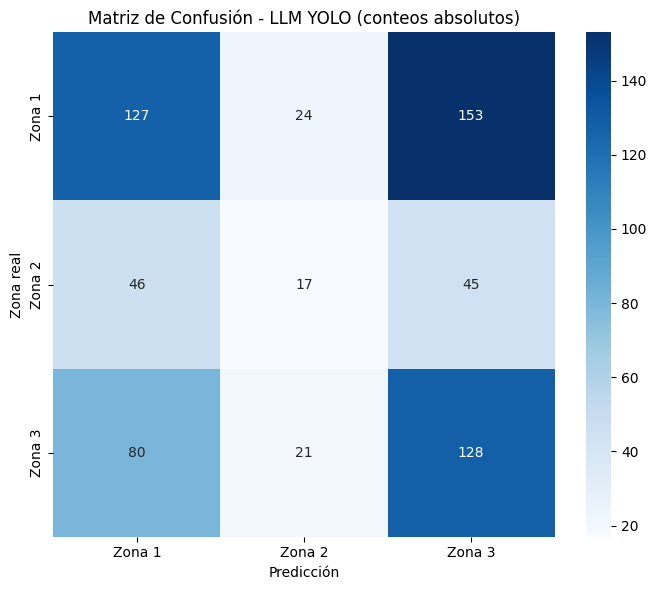

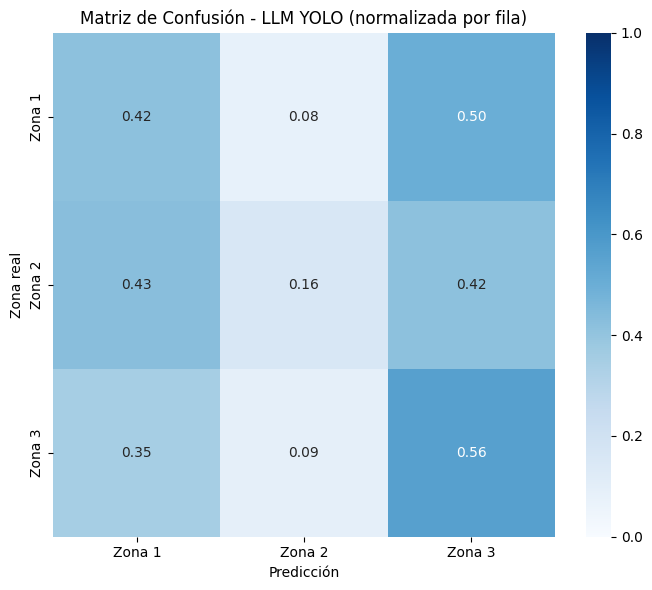

In [2]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales.csv", "yolo")